<a href="https://colab.research.google.com/github/mirza-javed/ML-practice/blob/main/Multi_linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('/content/drive/MyDrive/ML Learning/Datasets/multiple_linear_regression_dataset.csv')
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [3]:
df.shape

(20, 3)

In [4]:
df.isnull().sum()

,0
age,0
experience,0
income,0


In [5]:
df

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


In [6]:
from sklearn import linear_model
lr = linear_model.LinearRegression()
lr.fit(df[['age', 'experience']], df.income)


LinearRegression()

In [7]:
lr.predict([[29, 3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([34872.2371215])

In [8]:
lr.coef_

array([ -99.19535546, 2162.40419192])

In [9]:
lr.intercept_

np.float64(31261.68985410128)

In [10]:
lr.score(df[['age', 'experience']], df.income)

0.9773361310180797

In [11]:
import matplotlib.pyplot as plt

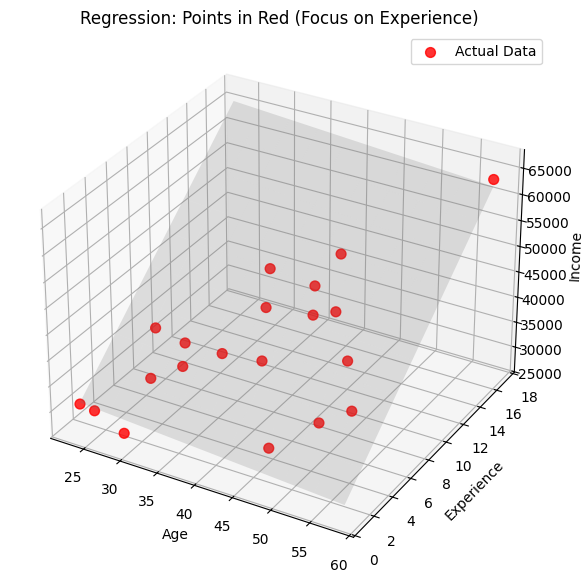

In [12]:
# This code is written by AI code generator.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

try:
    # Create a meshgrid for the features to plot the prediction plane
    x_surf, y_surf = np.meshgrid(np.linspace(df.age.min(), df.age.max(), 10),
                                 np.linspace(df.experience.min(), df.experience.max(), 10))

    # Prepare data for prediction
    plot_df = pd.DataFrame({'age': x_surf.ravel(), 'experience': y_surf.ravel()})
    predicted_income = lr.predict(plot_df)

    # Reshape the predictions to match the meshgrid shape
    z_surf = predicted_income.reshape(x_surf.shape)

    # Initialize the plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the actual data points - colored red based on experience
    # We use a colormap to emphasize the experience scale
    scatter = ax.scatter(df['age'], df['experience'], df['income'],
                         c='red', marker='o', alpha=0.8, s=50, label='Actual Data')

    # Plot the prediction surface
    ax.plot_surface(x_surf, y_surf, z_surf, color='gray', alpha=0.2)

    # Labels
    ax.set_xlabel('Age')
    ax.set_ylabel('Experience')
    ax.set_zlabel('Income')
    ax.set_title('Regression: Points in Red (Focus on Experience)')

    plt.legend()
    plt.show()
except NameError as e:
    print(f"Error: {e}. Please ensure you have run the cells that define 'df' and 'lr' first.")

In [13]:
import plotly

In [14]:
from plotly.graph_objs import Scatter, Layout

plotly.offline.plot({
    "data": [Scatter(x=df.age, y=df.income, mode='markers')],
    "layout": Layout(title="Age vs Income")
})

'temp-plot.html'

In [15]:
import pickle
with open('/content/drive/MyDrive/ML Learning/Datasets/model_pickle', 'wb') as f:
  pickle.dump(lr, f)

In [16]:
with open('/content/drive/MyDrive/ML Learning/Datasets/model_pickle', 'rb') as f:
    lr2 = pickle.load(f)

In [17]:
lr2.predict([[29, 3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([34872.2371215])

In [18]:
import joblib
joblib.dump(lr, '/content/drive/MyDrive/ML Learning/Datasets/model_joblib')

['/content/drive/MyDrive/ML Learning/Datasets/model_joblib']

In [19]:
lr3 = joblib.load('/content/drive/MyDrive/ML Learning/Datasets/model_joblib')


In [20]:
lr3.predict([[29, 3]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([34872.2371215])